In [2]:
import json
import os 
import numpy as np
from pathlib import Path
from read_json import read_json
from turnmill_process import TurnmillProcess

test_dir = Path.cwd().parent.parent.resolve() / "testdata/Diameter16Z4endmill"
test_paths = os.listdir(test_dir)

break_list = []
processes = []

In [3]:
for file in test_paths:
    if file.endswith('.json'):
        data_dict = read_json(os.path.join(test_dir, file))
        process = TurnmillProcess(data_dict, nChannels=3)
        channel_data = np.array([data_dict[f"Channel_{i}"]["Signal"] for i in range(1, 4)])
        num_samples = channel_data.shape[1]
        dt = 1 / data_dict["File_Header"]["SampleFrequency"]  # time interval between samples
        break_list.append(data_dict["break"])

        for j in range(channel_data.shape[1]):
            process.add_datapoint(timestamp=dt*j, values=channel_data[:, j].tolist())

        processes.append(process)

In [4]:
print(f"Number of breaks: {sum(break_list)}/{len(break_list)}")
print(test_paths)

Number of breaks: 39/71
['20.json', '61.json', '36.json', '41.json', '16.json', '57.json', '6.json', '7.json', '56.json', '17.json', '40.json', '37.json', '60.json', '21.json', '47.json', '10.json', '51.json', '0.json', '26.json', '67.json', '30.json', '31.json', '66.json', '70.json', '27.json', '1.json', '50.json', '11.json', '46.json', '69.json', '2.json', '28.json', '53.json', '12.json', '45.json', '32.json', '65.json', '24.json', '49.json', '48.json', '25.json', '64.json', 'ejemplo_json.zip', '33.json', '44.json', '13.json', '52.json', '29.json', '68.json', '3.json', '34.json', '63.json', '8.json', '22.json', '59.json', '18.json', '38.json', '4.json', '55.json', '14.json', '43.json', '42.json', '15.json', '54.json', '5.json', '39.json', '19.json', '58.json', '23.json', '62.json', '9.json', '35.json']


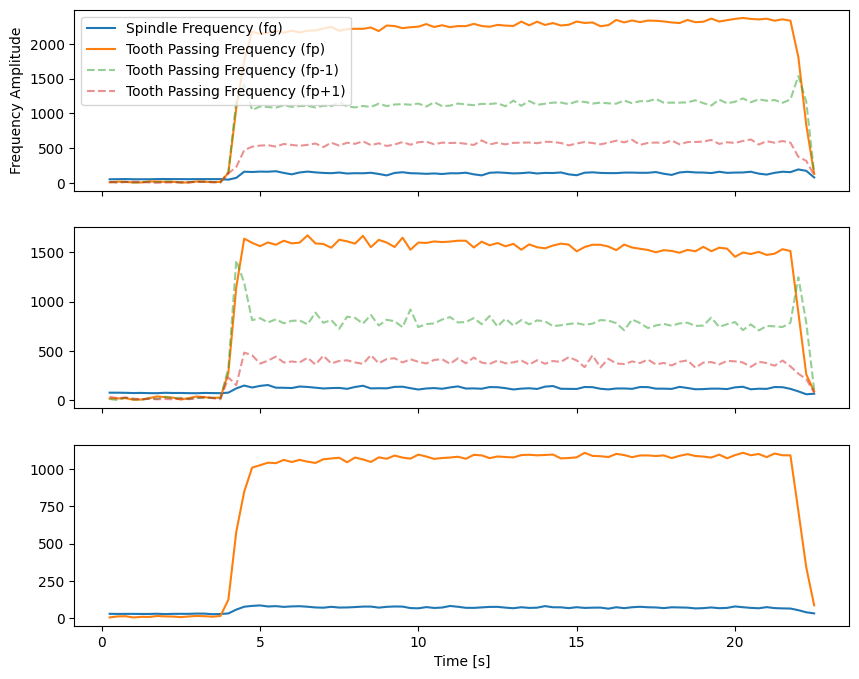

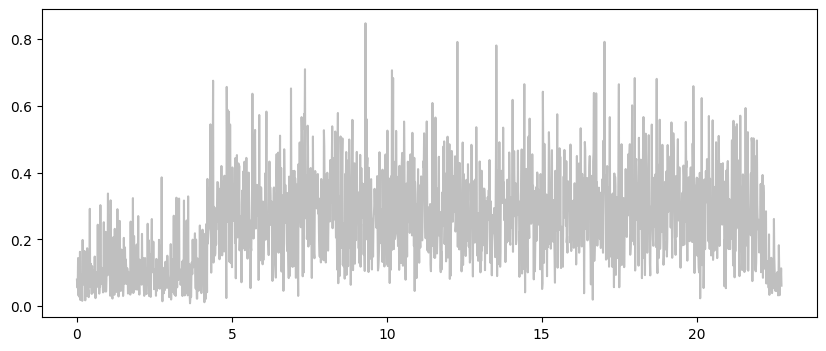

Broken:  True


In [ ]:
import matplotlib.pyplot as plt
index = 51
block_size = 2048
p = processes[index]
time = p.get_timestamps()
dt = time[1] - time[0]
freq = np.fft.rfftfreq(block_size, d=dt)

signal = np.array([p.get_channel_array(i) for i in range(3)])
spindle_freq = p.fg
tooth_passing_freq = p.fp

fg_idx = np.argmin(np.abs(freq - spindle_freq))
fp_idx = np.argmin(np.abs(freq - 2*tooth_passing_freq))
fp_idx_min = np.argmin(np.abs(freq - tooth_passing_freq)) - 1
fp_idx_plus = np.argmin(np.abs(freq - tooth_passing_freq)) + 1

time_segs = []
freqs = []
spindle_f = []
tooth_f = []
tooth_f_min = []
tooth_f_plus = []

iter = 0

while iter + block_size <= signal.shape[1]:
    seg_signal = signal[:, iter:iter+block_size]
    seg_time = time[iter:iter+block_size]

    f_signal = np.fft.rfft(seg_signal)

    spindle_f.append(f_signal[:, fg_idx])
    tooth_f_min.append(f_signal[:, fp_idx_min])
    tooth_f_plus.append(f_signal[:, fp_idx_plus])
    tooth_f.append(f_signal[:, fp_idx])
    time_segs.append(seg_time[block_size//2])
    iter += block_size//2

time_segs = np.array(time_segs)
spindle_f = np.array(spindle_f)
tooth_f = np.array(tooth_f)
tooth_f_min = np.array(tooth_f_min)
tooth_f_plus = np.array(tooth_f_plus)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(time_segs, np.abs(spindle_f[:, 0]), label='Spindle Frequency (fg)')
ax[0].plot(time_segs, np.abs(tooth_f[:, 0]), label='Tooth Passing Frequency (fp)')
ax[0].plot(time_segs, np.abs(tooth_f_min[:, 0]), label='Tooth Passing Frequency (fp-1)', linestyle='--', alpha=0.5)
ax[0].plot(time_segs, np.abs(tooth_f_plus[:, 0]), label='Tooth Passing Frequency (fp+1)', linestyle='--', alpha=0.5)
ax[0].set_ylabel('Frequency Amplitude')
ax[0].legend()

ax[1].plot(time_segs, np.abs(spindle_f[:, 1]), label='Spindle Frequency (fg)')
ax[1].plot(time_segs, np.abs(tooth_f[:, 1]), label='Tooth Passing Frequency (fp)')
ax[1].plot(time_segs, np.abs(tooth_f_min[:, 1]), label='Tooth Passing Frequency (fp-1)', linestyle='--', alpha=0.5)
ax[1].plot(time_segs, np.abs(tooth_f_plus[:, 1]), label='Tooth Passing Frequency (fp+1)', linestyle='--', alpha=0.5)

ax[2].plot(time_segs, np.abs(spindle_f[:, 2]), label='Spindle Frequency (fg)')
ax[2].plot(time_segs, np.abs(tooth_f[:, 2]), label='Tooth Passing Frequency (fp)')
ax[2].set_xlabel('Time [s]')
plt.show()

signal_norm = np.linalg.norm(signal, axis=0)
plt.figure(figsize=(10, 4))
plt.plot(time[::50], (signal_norm / np.max(signal_norm))[::50], label='Normalized Signal', color='gray', alpha=0.5)
plt.show()
print("Broken: ", break_list[index])


In [ ]:
#Independent Component Analysis (ICA)
import FastICA from sklearn.decomposition


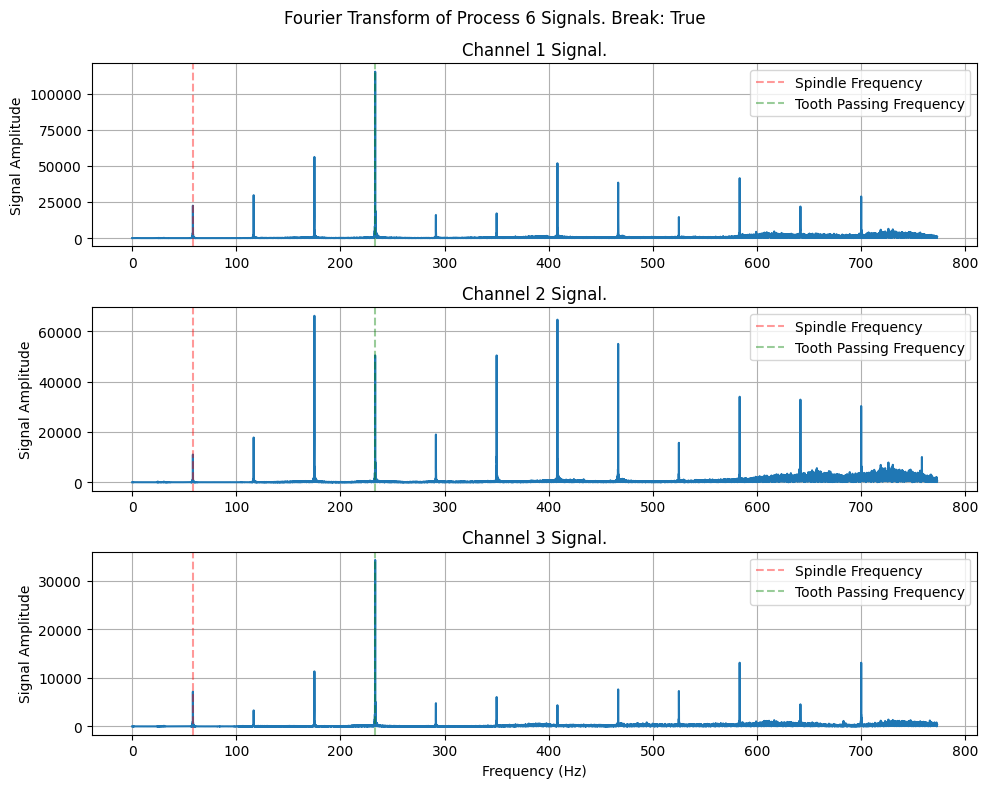

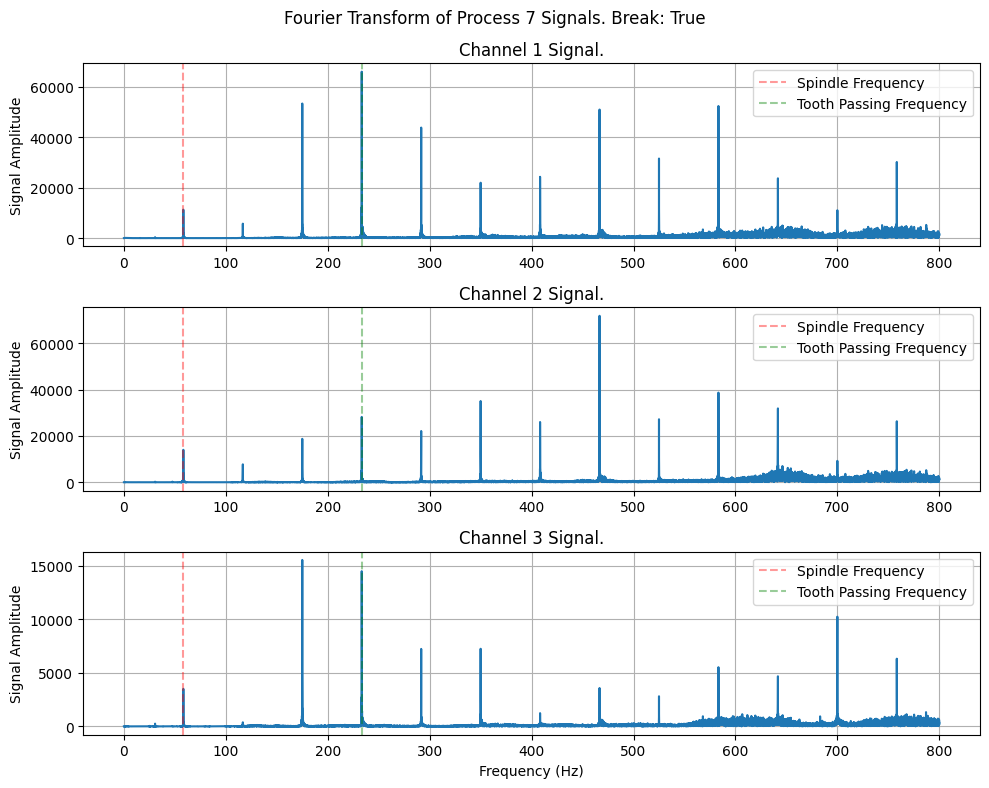

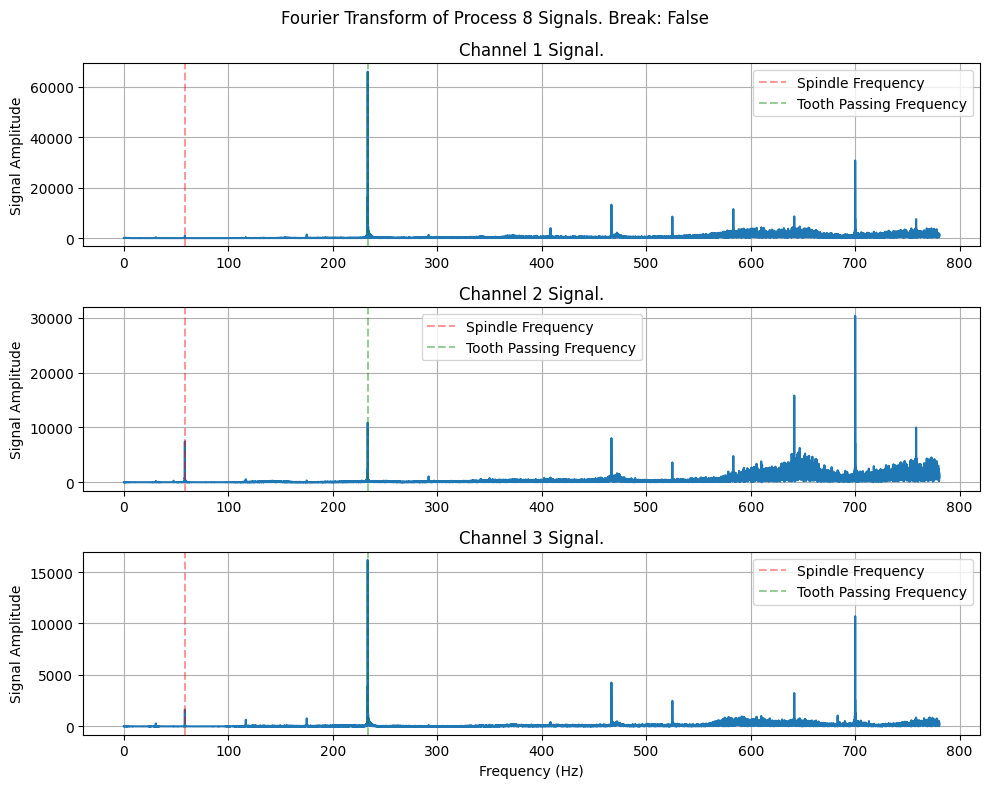

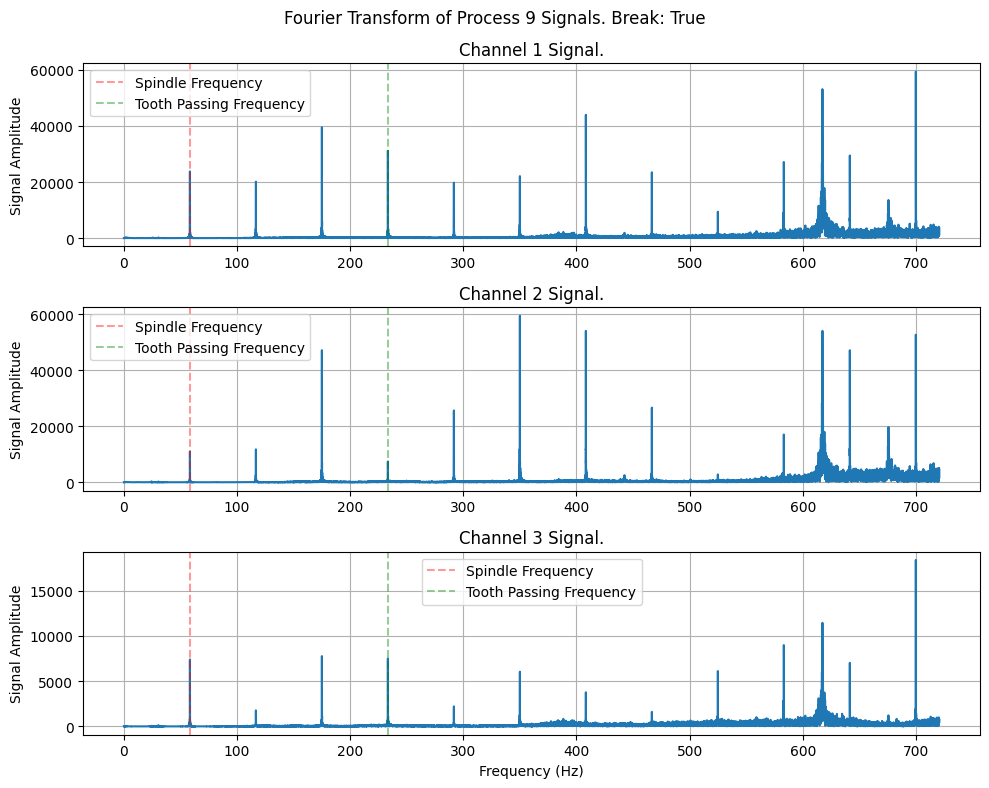

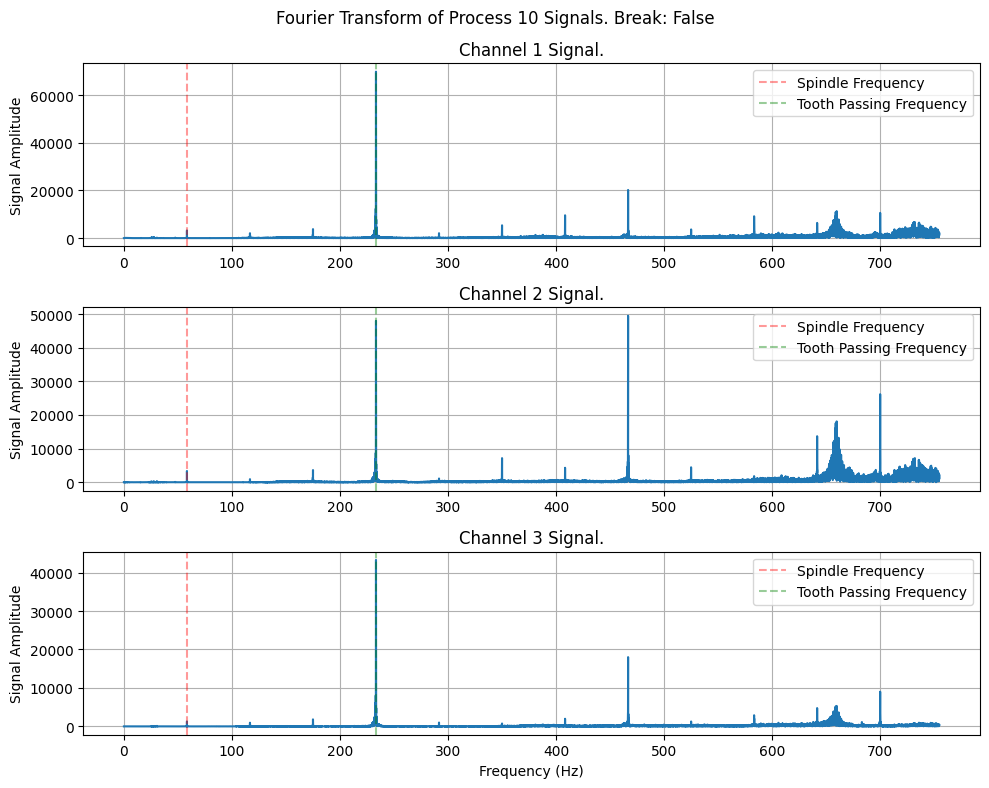

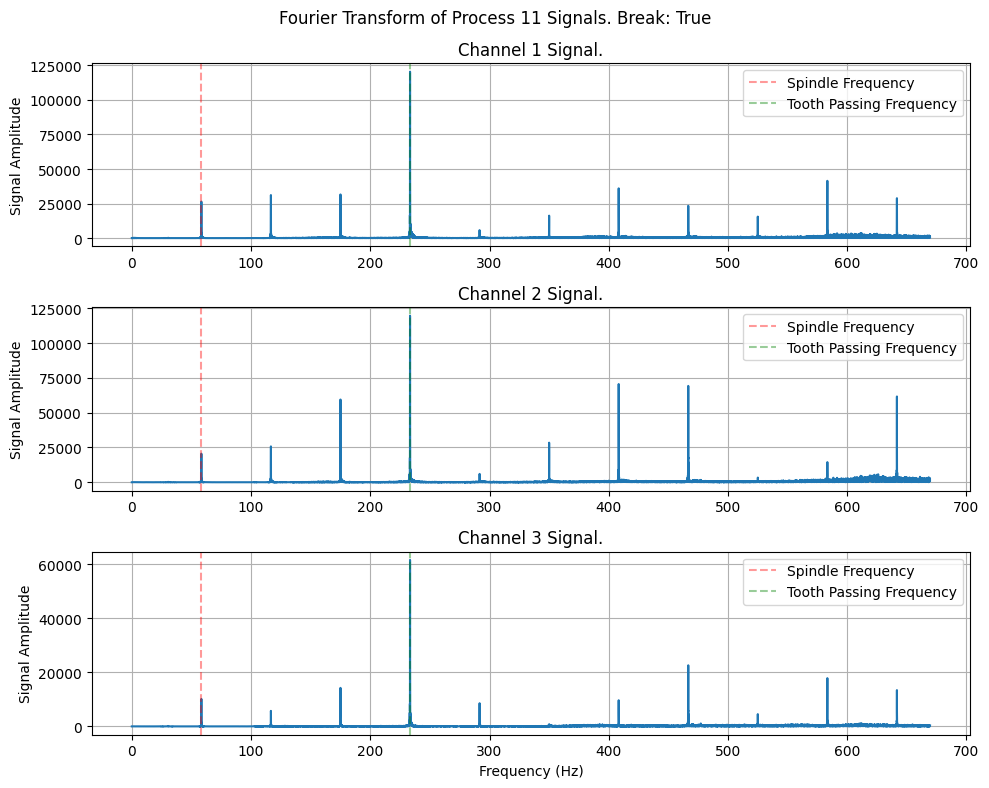

In [15]:
import matplotlib.pyplot as plt

for i in range(6, 12):
    #make 3 subplots for x, y, z acceleration
    fig, ax = plt.subplots(3, 1, figsize=(10, 8))
    p = processes[i]
    time = p.get_timestamps()
    for ch in range(3):
        signal = p.get_channel_array(ch)

        # Do fourier transform
        f_signal = np.fft.rfft(signal)
        freq = np.fft.rfftfreq(len(signal), d=(time[1]-time[0]))
        magnitude = np.abs(f_signal)

        ax[ch].plot(freq[:20000], magnitude[:20000])
        #vertical line at spindle and tooth passing frequencies
        spindle_freq = p.fg
        tooth_passing_freq = p.fp
        ax[ch].axvline(spindle_freq, color='r', linestyle='--', alpha = 0.4, label='Spindle Frequency')
        ax[ch].axvline(tooth_passing_freq, color='g', linestyle='--', alpha = 0.4, label='Tooth Passing Frequency')
        ax[ch].set_title(f'Channel {ch+1} Signal.')
        ax[ch].set_ylabel('Signal Amplitude')
        ax[ch].legend()
        ax[ch].grid()

    fig.suptitle(f'Fourier Transform of Process {i} Signals. Break: {break_list[i]}')

    ax[2].set_xlabel('Frequency (Hz)')

    plt.tight_layout()
    plt.show()
